|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|



## Exercice 7B9

<img src='../images/Chap-7-B9.png'>


## a)

Hagen-Poiseuille est la relation obtenue à la section 2.3 qui donne le débit en fonction de la différence de pression, elle est écrite en format de pression modifiée $\mathscr{P}_z=P_z+\rho g z$. 
<center>
$\begin{equation*}
  \boxed 
         {
  w=\frac{\rho \pi R^{4}( \mathscr{P_{0}} - \mathscr{P_{L}} ) }{8 L \mu} 
         }
  \end{equation*} $
</center>

ou en utilisant directement les pressions et la hauteur. ** Rappelons que quand la gravité est dans le sens opposé à l'axe $z$ on additionne le terme $\rho g z$ alors que quand la gravité est dans le même sens que l'axe on soustrait $\rho g z$ ** :

<center>
$\begin{equation*}
  \boxed 
         {
w= \frac{\rho \pi R^{4}}{8 L \mu} \left( P_{0} +\rho g 0 - P_{L} - \rho g L \right)
         }
  \end{equation*} $
</center>

En négligeant la friction dans le réservoir, Hagen-Poiseuille peut être utilisé pour déterminer le débit (volumétrique) pour ce problème spécifiquement. La pression à l'entrée de la conduite, en z=L, est donnée par $\rho g (L+H)$. Donc on peut remplacer les termes de pression par ceci, on a alors:

<center>
$\begin{equation*}
  \boxed 
         {
Q = \frac {dV}{dt}= -\frac{ \pi D^{4}}{128 L \mu} \left((L+H) g \rho \right)
         }
  \end{equation*} $ (1)
</center>

et en développant le volume en fonction de la hauteur H:

<center>
$\begin{equation*}
  \boxed 
         {
\pi R^2 \frac {dH}{dt}= -\frac{ \pi D^{4}}{128 L \mu} \left((L+H) g \rho \right)
         }
  \end{equation*} $ (2)
</center>

en simplifiant:

<center>
$\begin{equation*}
  \boxed 
         {
 \frac {dH}{dt}= -\frac{  D^{4}}{128 R^2 L \mu} \left( g \rho \right) (L+H)
         }
  \end{equation*} $ (3)
</center>

On peut maintenant solutionner en séparant et en intégrant

In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)

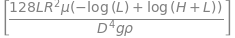

In [2]:
D,R,L,rho,g,mu,t_f,H=sp.symbols('D,R,L,rho,g,mu,t_f,H')
h,t=sp.symbols('h,t')
h=sp.integrate(1/(L+h),(h,H,0))
t=sp.integrate((D**4*g*rho)/(128*R**2*L*mu),(t,0,t_f))
solution=h+t
tf=sp.solve(solution,(t_f))
display(tf)

In [3]:

dico={'H':1,'mu':0.006,'L':.5,'D':0.001,'R':0.05,'g':9.81,'rho':900}
print('Pour ces conditions ',dico)
print('Temps de vidage ', tf[0].subs(dico).evalf(),' secondes', tf[0].subs(dico).evalf()/3600,' heures' )

Pour ces conditions  {'H': 1, 'mu': 0.006, 'L': 0.5, 'D': 0.001, 'R': 0.05, 'g': 9.81, 'rho': 900}
Temps de vidage  119454.954935031  secondes 33.1819319263974  heures


On peut calculer le nombre de Reynolds maximum qui est donné en utilisant le débit maximum, c'est-à-dire au début:

$\begin{equation*}
  \boxed 
         {
Q = \frac {dV}{dt}= -\frac{ \pi D^{4}}{128 L \mu} \left((L+H) g \rho \right)
         }
  \end{equation*} $

donc:

In [4]:
Q=(D**4*g*rho)/(128*R**2*L*mu)
Q=(Q.subs(dico).evalf())
Re=4*Q*rho/(sp.pi*D*mu)
print('Reynolds ',Re.subs(dico).evalf())

Reynolds  1756.47374069793
